## Load weather data from open-meteo with API request

* fetch weather data of the selected locations from 2019-01-01 till yesterday over open-meteo archive API
* get the latitude and longitude of the selected locations
* construct the request with header information with paramaters including the following
	- latitude and longitude of the selected locations
	- start and end date time, hourly, the weather variables to be requested
	- PV
		- shortwave_radiation, direct_radiation, diffuse_radiation, cloud_cover
	- Wind 
		- wind_speed_100m, wind_direction_100m
* calculate weighted weather data and ingest into database

In [1]:
# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})

from pathlib import Path
import os
import sys
import pandas as pd

# Ensure project modules are importable when notebook runs from notebook/
sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('../util'))
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
from src.config import *
from util.weather_weighted import *
from src.etl_price import *

In [2]:
# ------------- Test the weather weighting process on a short date range -----------------

# Keep this range short for fast iteration during development.
START_DATE = "2025-05-01"
END_DATE = "2025-05-07"

PV_CAPACITY_CSV = Path("../data/processed/pv_cluster_yearly_capacity_since_2019.csv")
WIND_CAPACITY_CSV = Path("../data/processed/wind_cluster_yearly_capacity_since_2019.csv")
WIND_LAND_CAPACITY_CSV = Path("../data/processed/wind_land_cluster_yearly_capacity_since_2019.csv")
WIND_SEA_CAPACITY_CSV = Path("../data/processed/wind_sea_cluster_yearly_capacity_since_2019.csv")

PV_OUTPUT_CSV = Path("../data/processed/pv_weather_weighted_hourly.csv")
WIND_OUTPUT_CSV = Path("../data/processed/wind_weather_weighted_hourly.csv")
WIND_LAND_OUTPUT_CSV = Path("../data/processed/wind_land_weather_weighted_hourly.csv")
WIND_SEA_OUTPUT_CSV = Path("../data/processed/wind_sea_weather_weighted_hourly.csv")

pv_weights_by_year = build_yearly_weights(PV_CAPACITY_CSV, technology_prefix="pv")
wind_weights_by_year = build_yearly_weights(WIND_CAPACITY_CSV, technology_prefix="wind")
wind_land_weights_by_year = build_yearly_weights(WIND_LAND_CAPACITY_CSV, technology_prefix="wind_land")
wind_sea_weights_by_year = build_yearly_weights(WIND_SEA_CAPACITY_CSV, technology_prefix="wind_sea")

print('PV cluster locations:\n', PV_CLUSTER_LOCATIONS)
print("PV weights by year:\n", pv_weights_by_year)

print('Wind cluster locations:\n', WIND_CLUSTER_LOCATIONS)
print("Wind weights by year:\n", wind_weights_by_year)

print('Wind Land cluster locations:\n', WIND_CLUSTER_LOCATIONS_LAND)
print("Wind Land weights by year:\n", wind_land_weights_by_year)

print('Wind Sea cluster locations:\n', WIND_CLUSTER_LOCATIONS_SEA)
print("Wind Sea weights by year:\n", wind_sea_weights_by_year)

df_weather_pv = fetch_weighted_weather_for_technology(
    technology_name="pv",
    locations=PV_CLUSTER_LOCATIONS,
    weather_variables=PV_WEATHER_VARIABLES,
    weights_by_year=pv_weights_by_year,
    start_date=START_DATE,
    end_date=END_DATE,
    selected_cities=SELECTED_CITIES,
    city_population=CITY_POPULATION,
    city_sleep=0.1,
 )

df_weather_wind = fetch_weighted_weather_for_technology(
    technology_name="wind",
    locations=WIND_CLUSTER_LOCATIONS,
    weather_variables=WIND_WEATHER_VARIABLES,
    weights_by_year=wind_weights_by_year,
    start_date=START_DATE,
    end_date=END_DATE,
    selected_cities=SELECTED_CITIES,
    city_population=CITY_POPULATION,
    city_sleep=0.1,
 )

df_weather_wind_land = fetch_weighted_weather_for_technology(
    technology_name="wind_land",
    locations=WIND_CLUSTER_LOCATIONS_LAND,
    weather_variables=WIND_WEATHER_VARIABLES,
    weights_by_year=wind_land_weights_by_year,
    start_date=START_DATE,
    end_date=END_DATE,
    selected_cities=SELECTED_CITIES,
    city_population=CITY_POPULATION,
    city_sleep=0.1,
 )

df_weather_wind_sea = fetch_weighted_weather_for_technology(
    technology_name="wind_sea",
    locations=WIND_CLUSTER_LOCATIONS_SEA,
    weather_variables=WIND_WEATHER_VARIABLES,
    weights_by_year=wind_sea_weights_by_year,
    start_date=START_DATE,
    end_date=END_DATE,
    selected_cities=SELECTED_CITIES,
    city_population=CITY_POPULATION,
    city_sleep=0.1,
 )

PV_OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df_weather_pv.to_csv(PV_OUTPUT_CSV, index=False)
df_weather_wind.to_csv(WIND_OUTPUT_CSV, index=False)
df_weather_wind_land.to_csv(WIND_LAND_OUTPUT_CSV, index=False)
df_weather_wind_sea.to_csv(WIND_SEA_OUTPUT_CSV, index=False)

print("PV rows:", len(df_weather_pv), "| Wind rows:", len(df_weather_wind), "| Wind Land rows:", len(df_weather_wind_land), "| Wind Sea rows:", len(df_weather_wind_sea))
print("PV columns:", list(df_weather_pv.columns))
print("Wind columns:", list(df_weather_wind.columns))
print("Wind Land columns:", list(df_weather_wind_land.columns))
print("Wind Sea columns:", list(df_weather_wind_sea.columns))
display(df_weather_pv.head(3))
display(df_weather_wind.head(3))
display(df_weather_wind_land.head(3))
display(df_weather_wind_sea.head(3))

PV cluster locations:
 {'pv_cluster_0': {'latitude': 48.25420811702128, 'longitude': 9.95483580319149}, 'pv_cluster_1': {'latitude': 53.2118939516129, 'longitude': 12.086464116935483}, 'pv_cluster_2': {'latitude': 50.08658111320755, 'longitude': 7.044273287735849}, 'pv_cluster_3': {'latitude': 51.5458006056338, 'longitude': 13.807042591549296}, 'pv_cluster_4': {'latitude': 48.98394633031674, 'longitude': 11.90809092760181}, 'pv_cluster_5': {'latitude': 49.92590152147239, 'longitude': 10.256971736196318}, 'pv_cluster_6': {'latitude': 54.19919941269841, 'longitude': 9.64202534920635}, 'pv_cluster_7': {'latitude': 52.31679351162791, 'longitude': 8.448149488372092}, 'pv_cluster_8': {'latitude': 53.1419551959799, 'longitude': 13.704316376884423}, 'pv_cluster_9': {'latitude': 51.541309815384615, 'longitude': 11.716682680769232}}
PV weights by year:
 {2019: {'pv_cluster_0': 0.04616220920135164, 'pv_cluster_1': 0.15552283873735914, 'pv_cluster_2': 0.04236968484705122, 'pv_cluster_3': 0.1806337

,time,shortwave_radiation,direct_radiation,diffuse_radiation,cloud_cover
0,2025-05-01 00:00:00+02:00,0.0,0.0,0.0,31.260001
1,2025-05-01 01:00:00+02:00,0.0,0.0,0.0,30.105123
2,2025-05-01 02:00:00+02:00,0.0,0.0,0.0,45.436027


,time,wind_speed_100m,wind_direction_100m
0,2025-05-01 00:00:00+02:00,16.300926,150.673668
1,2025-05-01 01:00:00+02:00,15.130130,116.245950
2,2025-05-01 02:00:00+02:00,14.421717,128.666786


,time,wind_speed_100m,wind_direction_100m
0,2025-05-01 00:00:00+02:00,15.739073,105.765347
1,2025-05-01 01:00:00+02:00,14.945965,115.055448
2,2025-05-01 02:00:00+02:00,14.635206,84.739860


,time,wind_speed_100m,wind_direction_100m
0,2025-05-01 00:00:00+02:00,20.616618,217.681450
1,2025-05-01 01:00:00+02:00,18.747123,238.752648
2,2025-05-01 02:00:00+02:00,19.743394,77.203313


In [8]:
# Update database with new weather data and inspect stored weather series
import sqlalchemy as sa

#update_database()

pv_ids = tuple(PV_WEATHER_SERIES_IDS.values())
wind_ids = tuple(WIND_WEATHER_SERIES_IDS.values())

query_pv = f"""
    SELECT time, series_id, value
    FROM timeseries_values
    WHERE series_id IN {pv_ids}
    ORDER BY time DESC, series_id
    """
query_wind = f"""
    SELECT time, series_id, value
    FROM timeseries_values
    WHERE series_id IN {wind_ids}
    ORDER BY time DESC, series_id
    """

engine = sa.create_engine("sqlite:///../db/energy_demand.db")
with engine.connect() as conn:
    df_agg_pv = pd.read_sql(query_pv, conn)
    df_agg_wind = pd.read_sql(query_wind, conn)

df_agg_pv['time'] = pd.to_datetime(df_agg_pv['time'])
df_agg_wind['time'] = pd.to_datetime(df_agg_wind['time'])

display(df_agg_pv.head())
display(df_agg_wind.head())

,time,series_id,value
0,2026-06-01 21:00:00+00:00,pv_weather_cloud_cover,78.635884
1,2026-06-01 21:00:00+00:00,pv_weather_diffuse_radiation,0.000000
2,2026-06-01 21:00:00+00:00,pv_weather_direct_radiation,0.000000
3,2026-06-01 21:00:00+00:00,pv_weather_shortwave_radiation,0.000000
4,2026-06-01 20:00:00+00:00,pv_weather_cloud_cover,73.028893


,time,series_id,value
0,2026-06-01 21:00:00+00:00,wind_weather_wind_direction_100m,172.847391
1,2026-06-01 21:00:00+00:00,wind_weather_wind_speed_100m,17.840506
2,2026-06-01 20:00:00+00:00,wind_weather_wind_direction_100m,165.382116
3,2026-06-01 20:00:00+00:00,wind_weather_wind_speed_100m,15.199610
4,2026-06-01 19:00:00+00:00,wind_weather_wind_direction_100m,195.368692


In [ ]:
df_agg_pv.describe()
df_agg_wind.describe()

## EDA weather data

* check validity, distribution
* check time cycle distribution

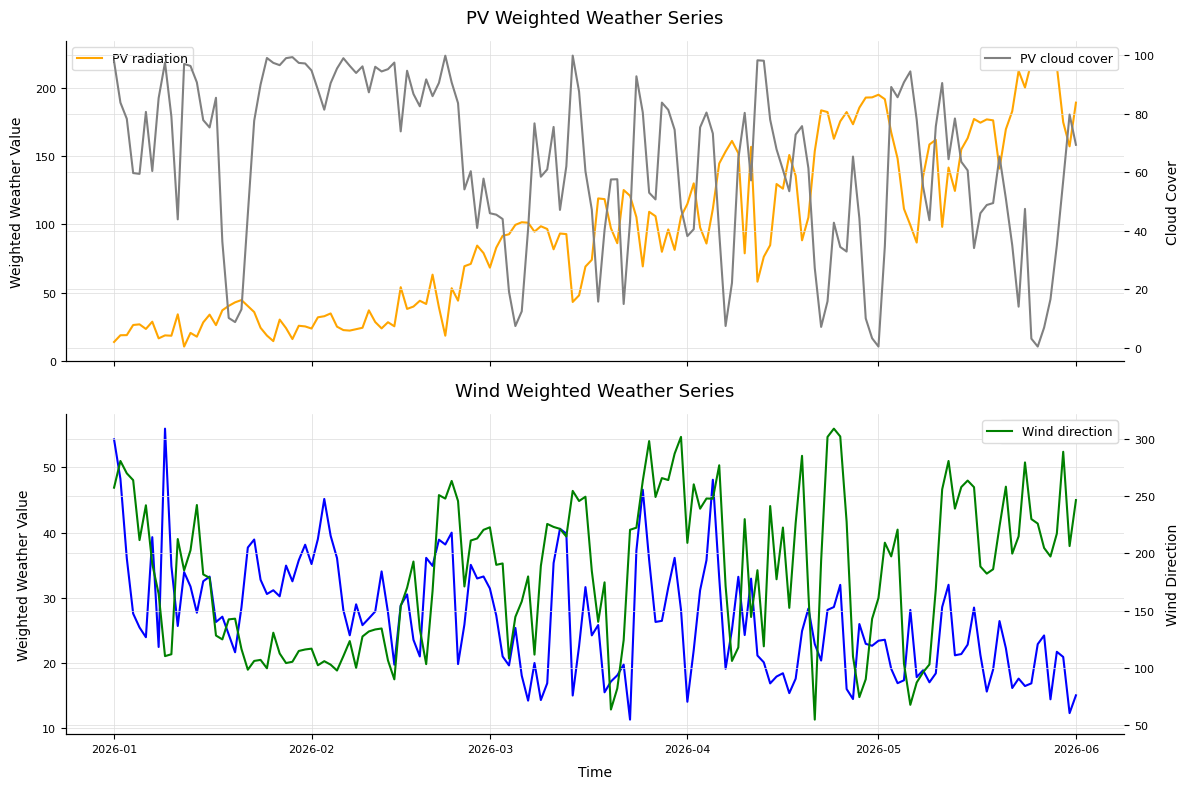

In [17]:
# Plot PV and wind weather series of 2026 for visual inspection
df_agg_pv_pivot = df_agg_pv.pivot(index='time', columns='series_id', values='value')

df_agg_pv_pivot = df_agg_pv.pivot(index="time", columns="series_id", values="value")
df_pv_2026 = df_agg_pv_pivot[df_agg_pv_pivot.index.year == 2026]
df_agg_pv_2026_daily = df_pv_2026.resample("D").mean().reset_index()

df_agg_pv_2026_daily["radiation"] = df_agg_pv_2026_daily.filter(regex="radiation").mean(axis=1)
df_agg_pv_2026_daily["cloud_cover"] = df_agg_pv_2026_daily.filter(regex="cloud_cover").mean(axis=1)

df_agg_wind_pivot = df_agg_wind.pivot(index="time", columns="series_id", values="value")
df_wind_2026 = df_agg_wind_pivot[df_agg_wind_pivot.index.year == 2026]
df_agg_wind_2026_daily = df_wind_2026.resample("D").mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 8),
                            sharex=True, sharey=False)  
axes[0].plot(df_agg_pv_2026_daily['time'], df_agg_pv_2026_daily['radiation'], label='PV radiation', color='orange')
axes_0_twinx = axes[0].twinx()
axes_0_twinx.plot(df_agg_pv_2026_daily['time'], df_agg_pv_2026_daily['cloud_cover'], label='PV cloud cover', color='grey')

axes[0].set_title('PV Weighted Weather Series')
axes[0].set_ylabel('Weighted Weather Value')
axes[0].legend()
axes_0_twinx.set_ylabel('Cloud Cover')
axes_0_twinx.legend(loc='upper right')

axes[1].plot(df_agg_wind_2026_daily['time'], df_agg_wind_2026_daily['wind_weather_wind_speed_100m'], label='Wind speed', color='blue')
axes_1_twinx = axes[1].twinx()
axes_1_twinx.plot(df_agg_wind_2026_daily['time'], df_agg_wind_2026_daily['wind_weather_wind_direction_100m'], label='Wind direction', color='green')
axes[1].set_title('Wind Weighted Weather Series')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Weighted Weather Value')
axes[1].legend()
axes_1_twinx.set_ylabel('Wind Direction')
axes_1_twinx.legend(loc='upper right')
plt.tight_layout()  
plt.show()